In [1]:
import pandas as pd
import requests

import os

from dotenv import load_dotenv

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [2]:
load_dotenv()
URL_BACKEND_PLAYERS = os.getenv('URL_BACKEND_PLAYERS')

In [3]:
def get_players():
    try:
        response = requests.get(URL_BACKEND_PLAYERS)
        if response.status_code == 200:
            return response.json()
        else:
            print(f'Error al obtener los jugadores: {response.status_code} - {response.text}')
            return None
    except Exception as e:
        print(f'Error con la conexión a la API de jugadores: {e}')
        return None

In [4]:
df = pd.DataFrame(get_players())
if df is not None:
    print('Datos cargados exitosamente')
else:
    print('No se puedo cargar los datos')

Datos cargados exitosamente


In [5]:
df.drop(columns='name')

,position,country_of_birth,height_in_cm,market_value_in_eur,club_id,id,last_season,age,club_name,league_id
0,Midfield,Germany,176.0,2000000,15,7161,2025,33,Bayer 04 Leverkusen Fußball,L1
1,Defender,Argentina,187.0,1000000,288,11111,2025,35,Club Estudiantes de La Plata,ARG1
2,Goalkeeper,Italy,184.0,1500000,6574,12907,2023,31,Unione Sportiva Sassuolo Calcio,IT1
3,Midfield,Brazil,185.0,8000000,985,16306,2025,34,Manchester United Football Club,GB1
4,Attack,Angola,185.0,1500000,458,22686,2012,32,Palermo FC,IT1
...,...,...,...,...,...,...,...,...,...,...
9556,Goalkeeper,Japan,183.0,0,2241,1494158,2025,23,Kashima Antlers FC,JAP1
9557,Midfield,Senegal,180.0,0,27,1497653,2025,18,FC Bayern München,L1
9558,Defender,Argentina,185.0,0,14687,1512081,2025,23,Club Atlético Gimnasia y Esgrima de Mendoza,ARG1
9559,Missing,Japan,182.0,0,672,1527143,2025,18,JEF United,JAP1


In [6]:
X = df[['position', 'club_name', 'age', 'last_season', 'league_id', 'country_of_birth', 'height_in_cm']]
y = df['market_value_in_eur']

In [7]:
categorical_features = [
    'position',
    'club_name',
    'league_id',
    'country_of_birth'
]

numerical_features = [
    'age',
    'last_season',
    'height_in_cm'
]

In [12]:
preprocessor = ColumnTransformer(
    transformers = [
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            categorical_features
        ),
    ],
    #Dejamos las columnas numéricas sin cambios
    remainder='passthrough'
)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('scaler', StandardScaler()), 
        ('model', LinearRegression(n_jobs=-1))
    ]
)

In [14]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['position','club_name','age',...,'league_id','country_of_birth', 'height_in_cm']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [15]:
predictions = pipeline.predict(X_test)

In [16]:
mae = mean_absolute_error(y_test, predictions) 
rmse = mean_squared_error(y_test, predictions) ** 0.5 
r2 = r2_score(y_test, predictions) 

print(f"MAE : {mae:,.2f} €") 
print(f"RMSE: {rmse:,.2f} €") 
print(f"R² : {r2:.4f}")

MAE : 4,305,081.58 €
RMSE: 8,791,182.02 €
R² : 0.2188


In [17]:
joblib.dump(pipeline, "../models/linear_regression_model.pkl")

['../models/linear_regression_model.pkl']

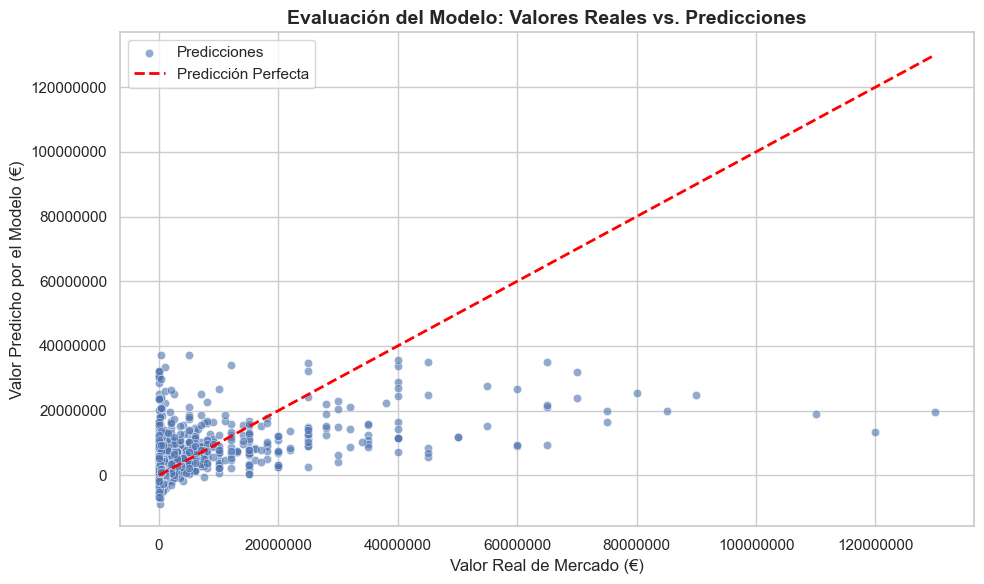

In [18]:
# Configuración del estilo del gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 1. Gráfico de dispersión: Valores Reales vs Predicciones
sns.scatterplot(x=y_test, y=predictions, alpha=0.6, color='b', label='Predicciones')

# 2. Línea de referencia ideal (Donde Realidad = Predicción)
# Si el modelo fuera perfecto (R² = 1.0), todos los puntos estarían sobre esta línea.
limite_max = max(max(y_test), max(predictions))
plt.plot([0, limite_max], [0, limite_max], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta')

# Personalización de etiquetas y títulos (asumiendo que y son Euros)
plt.title('Evaluación del Modelo: Valores Reales vs. Predicciones', fontsize=14, fontweight='bold')
plt.xlabel('Valor Real de Mercado (€)', fontsize=12)
plt.ylabel('Valor Predicho por el Modelo (€)', fontsize=12)
plt.legend(loc='upper left')

# Ajustar formato de los ejes para que muestre millones de forma limpia si los números son muy grandes
plt.ticklabel_format(style='plain', axis='both') 

# Mostrar el gráfico
plt.tight_layout()
plt.show()